In [1]:
import warnings
warnings.filterwarnings("ignore")

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.io_utils import load_csv_file, load_pickle_file
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima

from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
import torch

In [2]:
N = 5000
ind = torch.randint(0, N, (2,))#.item()
ind

tensor([ 86, 175])

In [3]:
mode_label = 0
name_isomer = ['ag6_planar', 'ag6_3d']
coord_mapping = Coordinates_mapping()

ag6_min = get_molecule_isomer_minima(name_isomer[mode_label])
ag6_rebuilt_min = coord_mapping.reorient_and_center_molecule(ag6_min)

zmat_md_full = load_csv_file('int_coords/is{:d}_md_zmat.csv'.format(mode_label))[:N, :]
zmat_md, logdetjac_to_xyz = zmat_md_full[:, :12], zmat_md_full[:, 12]

flow_model = load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label))['model']
xs_flow = flow_model.sample(N)
zmat_flow, logdetjac_to_xs = coord_mapping.get_internal_from_real_centered(xs_flow, isomer=mode_label)

ag6_md = coord_mapping.build_molecule_from_zmat(zmat_md[ind[0].item()])
ag6_flow = coord_mapping.build_molecule_from_zmat(zmat_flow[ind[1].item()])

ag6s = [ag6_min, ag6_rebuilt_min, ag6_md, ag6_flow]

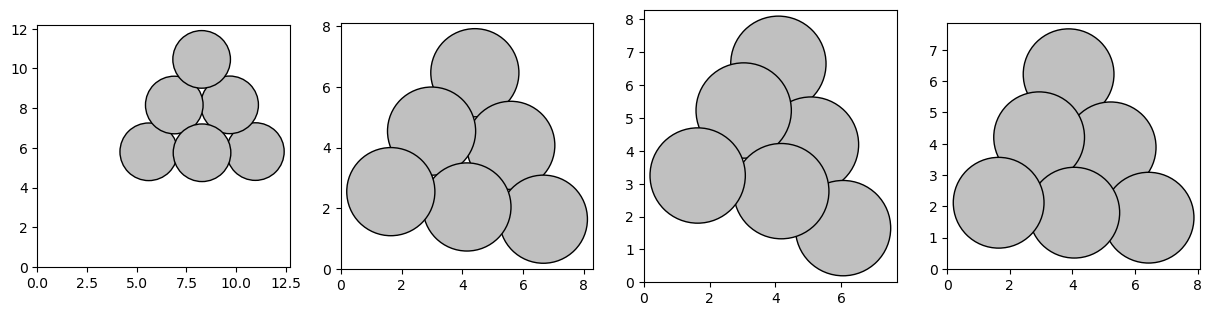

In [4]:
fig, axs = plt.subplots(1, len(ag6s), figsize=(15, 5))

for ag6,ax in zip(ag6s, axs):
    plot_atoms(ag6, ax)

In [5]:
zmats = [coord_mapping.get_zmat_from_molecule(ag6) for ag6 in ag6s]
xyzs = [coord_mapping._get_xyz_from_molecule(ag6) for ag6 in ag6s]

In [6]:
xyzs

[  atom          x          y    z
 0   Ag   7.980460   5.464791  8.0
 1   Ag   7.961142  10.164850  8.0
 2   Ag   6.583750   7.868667  8.0
 3   Ag   5.299389   5.513795  8.0
 4   Ag   9.369786   7.876240  8.0
 5   Ag  10.665305   5.524828  8.0,
   atom         x         y         z
 0   Ag -0.610402  0.810027 -0.764307
 1   Ag -0.349941  5.226757 -2.350366
 2   Ag -1.774265  3.305904 -1.145673
 3   Ag -3.115058  1.314049  0.050066
 4   Ag  0.831915  2.837079 -2.011743
 5   Ag  1.904246  0.407753 -1.616785,
   atom         x         y         z
 0   Ag -0.610402  0.810027 -0.764307
 1   Ag -0.698800  4.685153 -3.141765
 2   Ag -1.754506  3.263531 -1.139198
 3   Ag -3.154447  1.285801  0.075026
 4   Ag  0.293268  2.226132 -2.902600
 5   Ag  1.268579 -0.315127 -2.353740,
   atom         x         y         z
 0   Ag -0.610402  0.810027 -0.764307
 1   Ag -0.791804  5.233308 -2.694523
 2   Ag -1.733994  3.219543 -1.132477
 3   Ag -3.027522  1.127099  0.078491
 4   Ag  0.551871  2.897294 -2

In [7]:
zmats

[tensor([ 2.7802,  2.6824,  2.7860,  2.6847,  2.6874,  1.0257,  2.0728,  2.0717,
          1.0218,  0.0000,  0.0000, -3.1416], dtype=torch.float64),
 tensor([ 2.7802e+00,  2.6824e+00,  2.7860e+00,  2.6847e+00,  2.6874e+00,
          1.0257e+00,  2.0728e+00,  2.0717e+00,  1.0218e+00, -6.2832e+00,
          4.3725e-17, -3.1416e+00], dtype=torch.float64),
 tensor([ 2.7330,  2.7103,  2.8947,  2.7768,  2.6624,  1.0468,  1.9571,  2.0443,
          1.0005, -0.4481,  0.4373, -2.7655], dtype=torch.float64),
 tensor([ 2.6840,  2.7419,  2.6929,  2.6764,  2.7006,  0.9906,  2.1371,  1.9076,
          1.0560, -0.2356,  0.3892, -2.9312], dtype=torch.float64)]

In [8]:
int_coords_ldj = torch.stack([torch.cat(coord_mapping.get_internal_from_molecule(ag6)) for ag6 in ag6s])

In [9]:
import pandas as pd
from flonacomldft.internal_coordinates import get_labels_from_construction_table

labels = get_labels_from_construction_table(coord_mapping.construction_table) + ['logdetjac']
df = pd.DataFrame(data=int_coords_ldj, columns=labels)
df

,b-2-0,b-3-2,b-4-2,b-5-4,b-1-4,a-3-2-0,a-4-2-3,a-5-4-2,a-1-4-2,d-4-2-3-0,d-5-4-2-3,d-1-4-2-3,logdetjac
0,2.780183,2.682351,2.786046,2.684680,2.687380,1.025659,2.072824,2.071653,1.021774,0.000000,0.000000e+00,-3.141593,9.469965
1,2.780183,2.682351,2.786046,2.684680,2.687380,1.025659,2.072824,2.071653,1.021774,-6.283185,4.372485e-17,-3.141593,9.469965
2,2.732984,2.710276,2.894679,2.776774,2.662365,1.046835,1.957148,2.044346,1.000488,-0.448095,4.372613e-01,-2.765489,9.650482
3,2.683985,2.741893,2.692865,2.676444,2.700597,0.990601,2.137133,1.907632,1.055952,-0.235573,3.891619e-01,-2.931197,9.412239


In [10]:
zmat, logdetjac_to_xyz = int_coords_ldj[:, :12], int_coords_ldj[:, 12]
xs, logdetjac_to_zmat = coord_mapping.get_real_centered_from_internal(zmat, logdetjac_to_xyz, mode_label)

In [11]:
xs, logdetjac_to_xyz

(tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00, -4.4409e-16, -4.4409e-16,  4.4409e-16,  1.3323e-15,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  2.4493e-16,
           4.3725e-17,  0.0000e+00],
         [-4.7199e-02,  2.7925e-02,  1.0863e-01,  9.2093e-02, -2.5015e-02,
           2.1179e-02, -1.1619e-01, -2.7314e-02, -2.1289e-02, -4.8071e-01,
           4.6744e-01,  3.9490e-01],
         [-9.6198e-02,  5.9543e-02, -9.3181e-02, -8.2366e-03,  1.3217e-02,
          -3.5073e-02,  6.4398e-02, -1.6551e-01,  3.4191e-02, -2.4003e-01,
           4.1008e-01,  2.1356e-01]], dtype=torch.float64),
 tensor([ 9.4700,  9.4700, 10.2160,  9.7018], dtype=torch.float64))

In [12]:
from ase.io.trajectory import Trajectory
from flonacomldft.utils.io_utils import get_path

traj = Trajectory(get_path() + 'md_trajectories/ag6_is{:d}_lcao.traj'.format(mode_label))

In [13]:
ag6_md_traj = traj[ind[0].item()]
zmat, logdetjac_to_xyz, energies = coord_mapping.get_internal_from_molecule(ag6_md_traj, return_potential_energy=True)

In [14]:
zmat, logdetjac_to_xyz, energies

(tensor([ 2.7330,  2.7103,  2.8947,  2.7768,  2.6624,  1.0468,  1.9571,  2.0443,
          1.0005, -0.4481,  0.4373, -2.7655], dtype=torch.float64),
 tensor([9.6505], dtype=torch.float64),
 tensor([-6.7818], dtype=torch.float64))

In [15]:
zmat_md_full[ind[0].item(), :]

tensor([ 2.7330,  2.7103,  2.8947,  2.7768,  2.6624,  1.0468,  1.9571,  2.0443,
         1.0005, -0.4481,  0.4373, -2.7655,  9.6505, -6.7818,  0.0000])

In [16]:
xs, logdetjac_to_zmat, energies = coord_mapping.get_real_centered_from_internal(zmat.reshape(1, -1), logdetjac_to_xyz, mode_label, energies=energies)

In [17]:
xs, logdetjac_to_zmat, energies

(tensor([[-0.0472,  0.0279,  0.1086,  0.0921, -0.0250,  0.0212, -0.1162, -0.0273,
          -0.0213, -0.4807,  0.4674,  0.3949]], dtype=torch.float64),
 tensor([10.2160], dtype=torch.float64),
 tensor([-6.7964], dtype=torch.float64))

In [18]:
mlp_model = load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label))['model']

mlp_model(xs.float())

tensor([[-6.7950]], grad_fn=<AddmmBackward0>)

In [19]:
# PROCESS FOR LOADING NEW SAMPLE FOR DFT AND THEN COME BACK TO REAL CENTERED

In [20]:
zmat, logdetjac = coord_mapping.get_internal_from_real_centered(xs, isomer=mode_label)
zmat[0], logdetjac

(tensor([ 2.7330,  2.7103,  2.8947,  2.7768,  2.6624,  1.0468,  1.9566,  2.0443,
          1.0005, -0.4807,  0.4674, -2.7467], dtype=torch.float64),
 tensor([-0.5655], dtype=torch.float64))

In [21]:
xyz, logdetjac = coord_mapping.get_cartesian_from_internal(zmat[0], logdetjac)
xyz, logdetjac

(  atom         x         y         z
 0   Ag -0.610402  0.810027 -0.764307
 1   Ag -0.755627  4.688558 -3.168311
 2   Ag -1.754506  3.263532 -1.139198
 3   Ag -3.154454  1.285806  0.075027
 4   Ag  0.234947  2.225483 -2.967775
 5   Ag  1.238312 -0.309647 -2.441614,
 tensor([-10.2162], dtype=torch.float64))

In [27]:
from ase.visualize import view
view(coord_mapping._build_molecule_from_xyz(xyz))

<Popen: returncode: None args: ['/home/ana/anaconda3/envs/ml-dft/bin/python'...>

In [24]:
energy_xyz = ag6_md_traj.get_potential_energy()
coord_mapping.compute_energy_in_new_frame(energy_xyz, logdetjac*(-1))

tensor([-6.7964], dtype=torch.float64)

In [23]:
energy_xyz

-6.5323388976609325